# Исследование рынка подержанных автомобилей

### Цель: оказать помощь пользователю ориентироваться в ценах, выбирать наиболее ликвидные бренды и принимать обоснованное решение при покупке подержанного автомобиля.

### Импорт необходимых библиотек и загрузка датасета данных

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

file_path = '/content/sample_data/vehicles.csv'
df = pd.read_csv(file_path)

print("Данные загружены. Размер:", df.shape)
print("\nДоступные колонки:")
print(df.columns.tolist())

Данные загружены. Размер: (96421, 26)

Доступные колонки:
['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color', 'image_url', 'description', 'county', 'state', 'lat', 'long', 'posting_date']


### Очистка и подготовка данных

In [38]:
# Удалим дубликаты
df = df.drop_duplicates(subset=['id'])

# Удалим строки без цены и года (ключевые поля)
df = df.dropna(subset=['price', 'year'])

# Фильтрация разумных цен (от 500 до 200 000 $)
df = df[(df['price'] > 500) & (df['price'] < 200000)]

# Фильтрация разумных годов (от 1980 до 2025)
df = df[(df['year'] >= 1980) & (df['year'] <= 2025)]

# Заполним пропуски в производителе значением 'Unknown'
df['manufacturer'] = df['manufacturer'].fillna('Unknown')

# Фильтрация разумного пробега (до 500 000 миль)
if 'odometer' in df.columns:
    df = df[df['odometer'] < 500000]

print(f"\nПосле очистки: {len(df):,} записей")
print(f"Диапазон цен: ${df['price'].min():,.0f} - ${df['price'].max():,.0f}")
print(f"Диапазон годов: {df['year'].min()} - {df['year'].max()}")


После очистки: 82,511 записей
Диапазон цен: $501 - $199,999
Диапазон годов: 1980.0 - 2022.0


### Описательная статистика

In [40]:
print(df['price'].describe())
print("\n   Описательная статистика (года)")
print(df['year'].describe())

if 'odometer' in df.columns:
    print("\n   Описательная статистика (пробег)")
    print(df['odometer'].describe())

count     82511.000000
mean      19411.861461
std       14585.966923
min         501.000000
25%        8200.000000
50%       15995.000000
75%       27590.000000
max      199999.000000
Name: price, dtype: float64

   Описательная статистика (года)
count    82511.000000
mean      2011.803966
std          6.637014
min       1980.000000
25%       2008.000000
50%       2013.000000
75%       2017.000000
max       2022.000000
Name: year, dtype: float64

   Описательная статистика (пробег)
count     82511.000000
mean      92493.059071
std       63753.563947
min           0.000000
25%       38871.000000
50%       86492.000000
75%      133504.000000
max      498572.000000
Name: odometer, dtype: float64


### Распределение цен

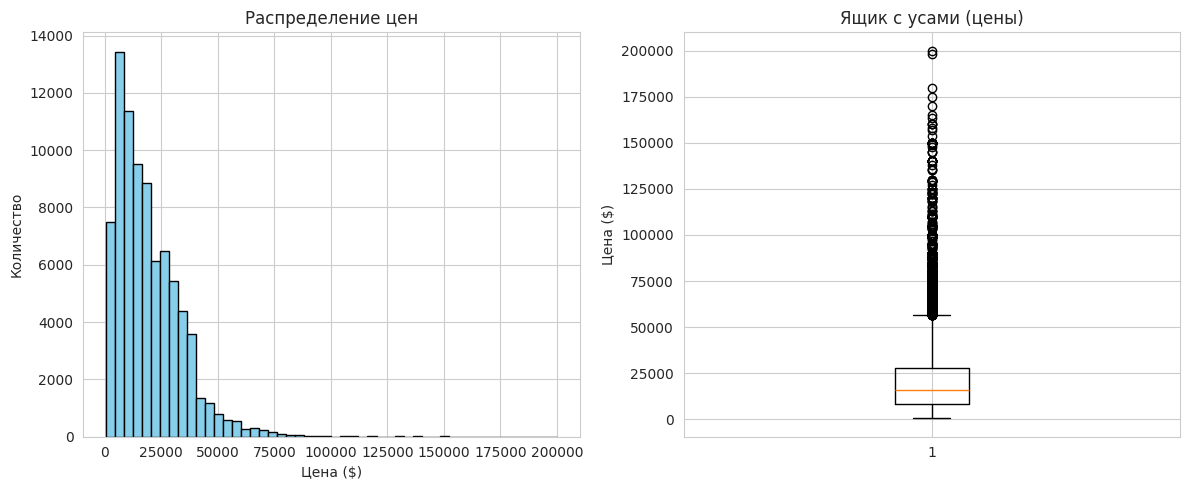

In [46]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['price'], bins=50, color='skyblue', edgecolor='black')
plt.title('Распределение цен')
plt.xlabel('Цена ($)')
plt.ylabel('Количество')

plt.subplot(1, 2, 2)
plt.boxplot(df['price'])
plt.title('Ящик с усами (цены)')
plt.ylabel('Цена ($)')
plt.tight_layout()
plt.show()

### Зависимость цены от года и пробега

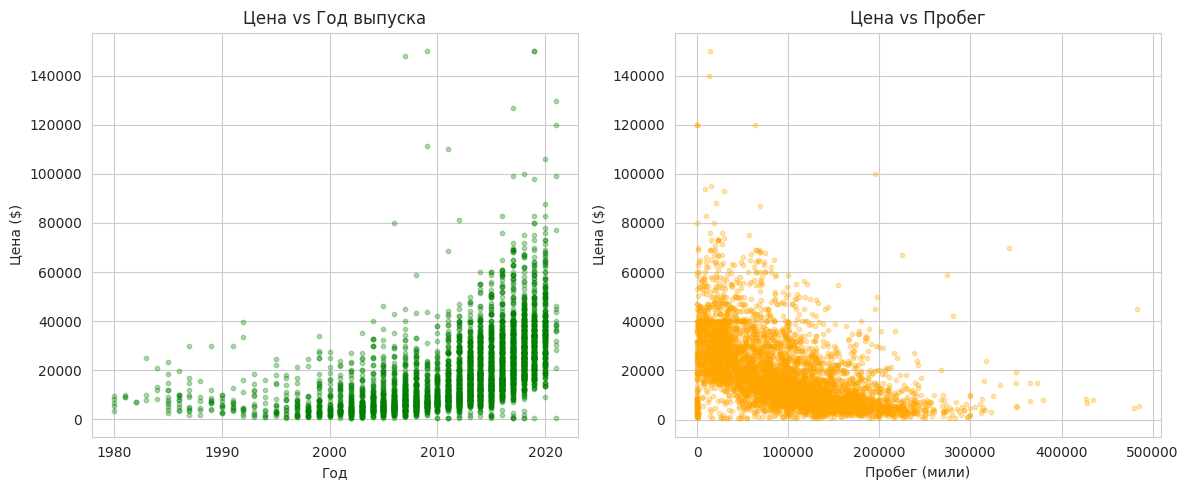


Корреляция цены и года выпуска: 0.53
Корреляция цены и пробега: -0.52


In [47]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# Возьмём выборку для ускорения (каждую 10-ю строку)
sample = df.sample(min(5000, len(df)))
plt.scatter(sample['year'], sample['price'], alpha=0.3, color='green', s=10)
plt.title('Цена vs Год выпуска')
plt.xlabel('Год')
plt.ylabel('Цена ($)')

if 'odometer' in df.columns:
    plt.subplot(1, 2, 2)
    sample_odo = df.sample(min(5000, len(df)))
    plt.scatter(sample_odo['odometer'], sample_odo['price'], alpha=0.3, color='orange', s=10)
    plt.title('Цена vs Пробег')
    plt.xlabel('Пробег (мили)')
    plt.ylabel('Цена ($)')

plt.tight_layout()
plt.show()

# Корреляция
corr_price_year = df['price'].corr(df['year'])
print(f"\nКорреляция цены и года выпуска: {corr_price_year:.2f}")

if 'odometer' in df.columns:
    corr_price_odometer = df['price'].corr(df['odometer'])
    print(f"Корреляция цены и пробега: {corr_price_odometer:.2f}")

### Анализ по производителям


   Топ-20 производителей по количеству объявлений
               количество  средняя_цена  медианная_цена
manufacturer                                           
ford                12074  21426.182458         17283.0
chevrolet            9260  21596.118359         17995.0
toyota               8087  17071.388030         13900.0
honda                4891  12658.316091          9999.0
nissan               3976  13794.975855         11900.0
jeep                 3346  21010.831142         18999.0
bmw                  3282  20068.228215         17995.0
ram                  3182  31255.133878         29992.5
mercedes-benz        2748  23152.804949         19995.0
gmc                  2703  25726.500925         24990.0
hyundai              2256  13106.479610         11917.0
dodge                2237  17257.178811         13999.0
subaru               2214  14270.575429         11995.0
lexus                2118  19720.791313         18500.0
volkswagen           1901  14165.529195         13500

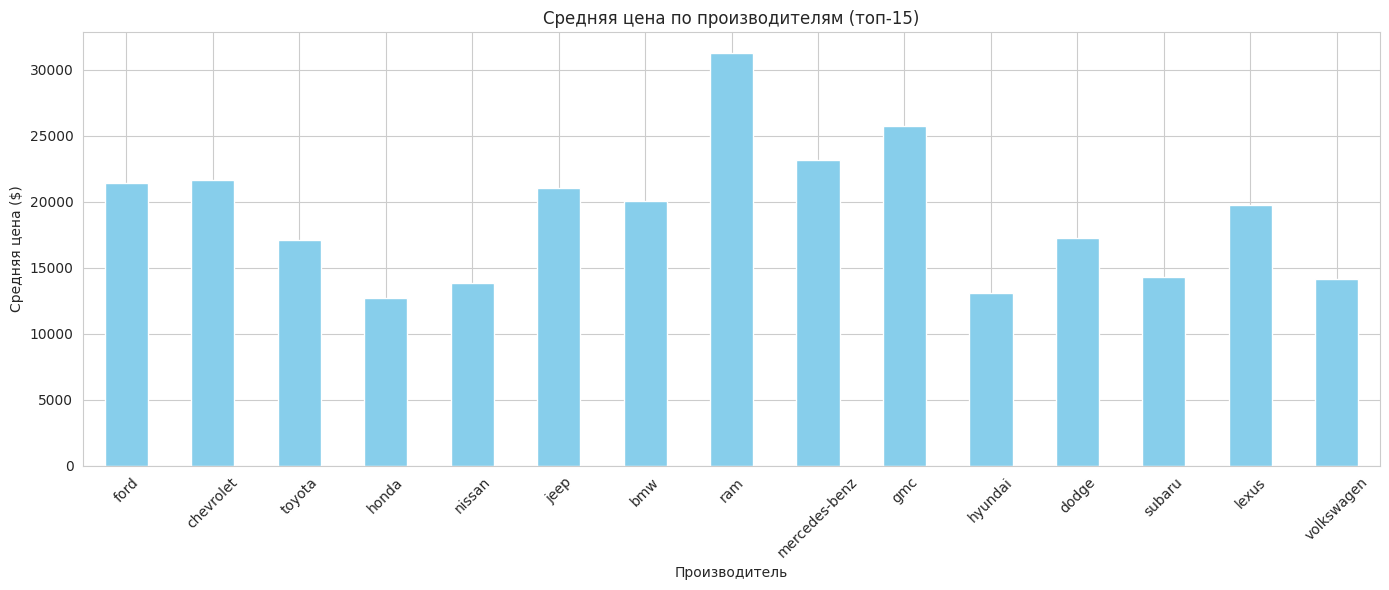

In [48]:
manufacturer_stats = df[df['manufacturer'] != 'Unknown'].groupby('manufacturer').agg(
    количество=('price', 'count'),
    средняя_цена=('price', 'mean'),
    медианная_цена=('price', 'median')
).sort_values('количество', ascending=False).head(20)

print("\n   Топ-20 производителей по количеству объявлений")
print(manufacturer_stats)

plt.figure(figsize=(14, 6))
manufacturer_stats['средняя_цена'].head(15).plot(kind='bar', color='skyblue')
plt.title('Средняя цена по производителям (топ-15)')
plt.xlabel('Производитель')
plt.ylabel('Средняя цена ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Анализ по состоянию


   Анализ по состоянию автомобиля
           количество  средняя_цена
condition                          
good            25449  21120.048411
excellent       22667  16306.544316
like new         3980  20563.335678
fair             1298   3881.348998
new               193  35060.176166
salvage           124   3977.669355


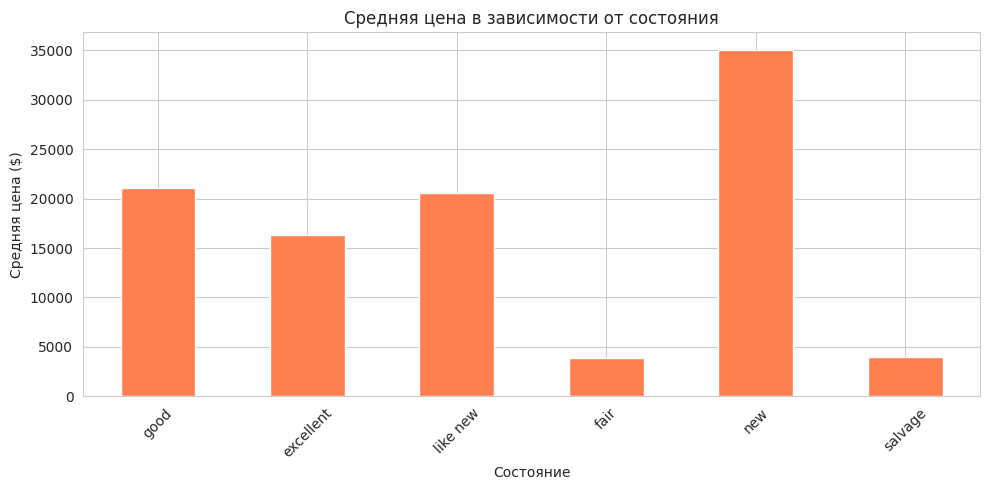

In [49]:
if 'condition' in df.columns:
    condition_stats = df.groupby('condition').agg(
        количество=('price', 'count'),
        средняя_цена=('price', 'mean')
    ).sort_values('количество', ascending=False)

    print("\n   Анализ по состоянию автомобиля")
    print(condition_stats)

    plt.figure(figsize=(10, 5))
    condition_stats['средняя_цена'].plot(kind='bar', color='coral')
    plt.title('Средняя цена в зависимости от состояния')
    plt.xlabel('Состояние')
    plt.ylabel('Средняя цена ($)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Анализ по типу топлива


   Анализ по типу топлива
          количество  средняя_цена
fuel                              
gas            68210  17484.976719
other           6637  28527.173120
diesel          5219  33635.037555
hybrid          1475  15908.587797
electric         511  22735.007828


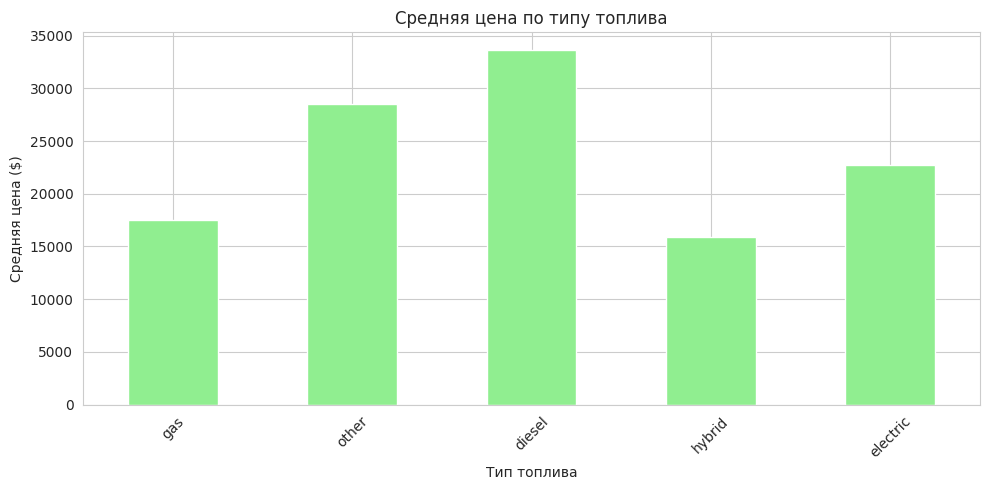

In [50]:
if 'fuel' in df.columns:
    fuel_stats = df.groupby('fuel').agg(
        количество=('price', 'count'),
        средняя_цена=('price', 'mean')
    ).sort_values('количество', ascending=False)

    print("\n   Анализ по типу топлива")
    print(fuel_stats)

    plt.figure(figsize=(10, 5))
    fuel_stats['средняя_цена'].plot(kind='bar', color='lightgreen')
    plt.title('Средняя цена по типу топлива')
    plt.xlabel('Тип топлива')
    plt.ylabel('Средняя цена ($)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Анализ по типу трансмиссии

In [52]:
if 'transmission' in df.columns:
    transmission_stats = df.groupby('transmission').agg(
        количество=('price', 'count'),
        средняя_цена=('price', 'mean')
    ).sort_values('количество', ascending=False)

    print("\n   Анализ по типу трансмиссии")
    print(transmission_stats)


   Анализ по типу трансмиссии
              количество  средняя_цена
transmission                          
automatic          63312  18045.738533
other              13789  27668.254696
manual              5122  13911.400820


### Анализ по штатам

In [53]:
if 'state' in df.columns:
    state_stats = df.groupby('state').agg(
        количество=('price', 'count'),
        средняя_цена=('price', 'mean')
    ).sort_values('количество', ascending=False).head(10)

    print("\n   Топ-10 штатов по количеству объявлений")
    print(state_stats)


   Топ-10 штатов по количеству объявлений
       количество  средняя_цена
state                          
ca          41717  18947.903037
co           9958  19258.963647
az           7650  20799.137778
ct           4819  15345.838556
al           4482  21284.537260
fl           3922  21211.754207
ak           3338  24267.232774
ar           3151  22513.473183
dc           2616  15903.489297
de            858  16619.311189


### Итоговые выводы

In [55]:
print(f"""
ФАКТЫ по данным выборки:
• Всего автомобилей в выборке: {len(df):,}
• Средняя цена: ${df['price'].mean():,.0f}
• Медианная цена: ${df['price'].median():,.0f}
• Средний год выпуска: {df['year'].mean():.0f}
• Диапазон годов: {df['year'].min()} - {df['year'].max()}

КОРРЕЛЯЦИЯ:
• Цена и год выпуска: {corr_price_year:.2f} (чем новее, тем дороже)
""")

if 'odometer' in df.columns:
    print(f"• Цена и пробег: {corr_price_odometer:.2f} (чем больше пробег, тем дешевле)")

print(f"""
ПОПУЛЯРНЫЕ ПРОИЗВОДИТЕЛИ:
• {manufacturer_stats.index[0]} — {manufacturer_stats.iloc[0]['количество']:,.0f} объявлений
• {manufacturer_stats.index[1]} — {manufacturer_stats.iloc[1]['количество']:,.0f} объявлений
• {manufacturer_stats.index[2]} — {manufacturer_stats.iloc[2]['количество']:,.0f} объявлений

РЕКОМЕНДАЦИИ:
• Наиболее ликвидные бренды: {', '.join(manufacturer_stats.head(3).index.tolist())}
• Оптимальный год выпуска для покупки: {df['year'].median():.0f}
• При переговорах ориентируйтесь на медианную цену (${df['price'].median():,.0f})
• Автомобили с пробегом более 100 000 миль значительно дешевле
""")


ФАКТЫ по данным выборки:
• Всего автомобилей в выборке: 82,511
• Средняя цена: $19,412
• Медианная цена: $15,995
• Средний год выпуска: 2012
• Диапазон годов: 1980.0 - 2022.0

КОРРЕЛЯЦИЯ:
• Цена и год выпуска: 0.53 (чем новее, тем дороже)

• Цена и пробег: -0.52 (чем больше пробег, тем дешевле)

ПОПУЛЯРНЫЕ ПРОИЗВОДИТЕЛИ:
• ford — 12,074 объявлений
• chevrolet — 9,260 объявлений
• toyota — 8,087 объявлений

РЕКОМЕНДАЦИИ:
• Наиболее ликвидные бренды: ford, chevrolet, toyota
• Оптимальный год выпуска для покупки: 2013
• При переговорах ориентируйтесь на медианную цену ($15,995)
• Автомобили с пробегом более 100 000 миль значительно дешевле

